# 02 ? Bivariate Analysis (Hypothesis Visualization)

This notebook focuses on **visualizing relationships** aligned to the hypotheses in `problem_definition.txt`.

Important notes:
- This notebook **does not perform hypothesis testing** (no p-values / model inference). It is descriptive/visual only.
- The dataset has **no timestamps**, so retention and time-window repeat KPIs are approximated with within-dataset engagement proxies (e.g., `repeat_customer_flag`, `n_orders`).
- If `*.new.csv` versions exist (created when original CSVs were locked), this notebook will automatically load those instead.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

In [2]:
def resolve_processed_path(stem: str) -> Path:
    base = Path("data/processed")
    new_path = base / f"{stem}.new.csv"
    old_path = base / f"{stem}.csv"
    return new_path if new_path.exists() else old_path

orders_path = resolve_processed_path("orders_features")
customers_path = resolve_processed_path("customer_features")
restaurants_path = resolve_processed_path("restaurant_features")
cuisines_path = resolve_processed_path("cuisine_features")

orders = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\orders_features.new.csv")
customers = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\customer_features.new.csv")
restaurants = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\restaurant_features.new.csv")
cuisines = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\cuisine_features.new.csv")

orders_path, customers_path, restaurants_path, cuisines_path

(WindowsPath('data/processed/orders_features.csv'),
 WindowsPath('data/processed/customer_features.csv'),
 WindowsPath('data/processed/restaurant_features.csv'),
 WindowsPath('data/processed/cuisine_features.csv'))

In [3]:
def quick_check(df: pd.DataFrame, name: str):
    print(f"{name}: shape={df.shape}")
    miss = df.isna().mean().mul(100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        print("  missing: none")
    else:
        print("  missing top (%):")
        display(miss.head(10).to_frame("missing_%").round(3))

quick_check(orders, "orders")
quick_check(customers, "customers")
quick_check(restaurants, "restaurants")
quick_check(cuisines, "cuisines")

orders: shape=(1898, 16)
  missing top (%):


,missing_%
top_rating_flag,38.778
high_rating_flag,38.778
rating_num,38.778


customers: shape=(1200, 26)
  missing top (%):


,missing_%
std_prep_time,65.333
std_cost,65.333
std_delivery_time,65.333
std_total_fulfillment_time,65.333
delivery_time_cv,65.333
total_time_cv,65.333
avg_rating,28.417
pct_high_rating,28.417
pct_top_rating,28.417


restaurants: shape=(178, 16)
  missing top (%):


,missing_%
delivery_time_cv,28.09
std_delivery_time,28.09
pct_high_rating,12.36
avg_rating,12.36
pct_top_rating,12.36


cuisines: shape=(14, 10)
  missing: none


## H1: Faster & more consistent delivery ? higher repeat/retention (proxy)

Retention is approximated using within-dataset engagement proxies:
- `repeat_customer_flag` (>=2 orders)
- `n_orders`

Delivery experience proxies:
- `avg_delivery_time`, `avg_total_fulfillment_time`
- `std_delivery_time`, `delivery_time_cv` (consistency)

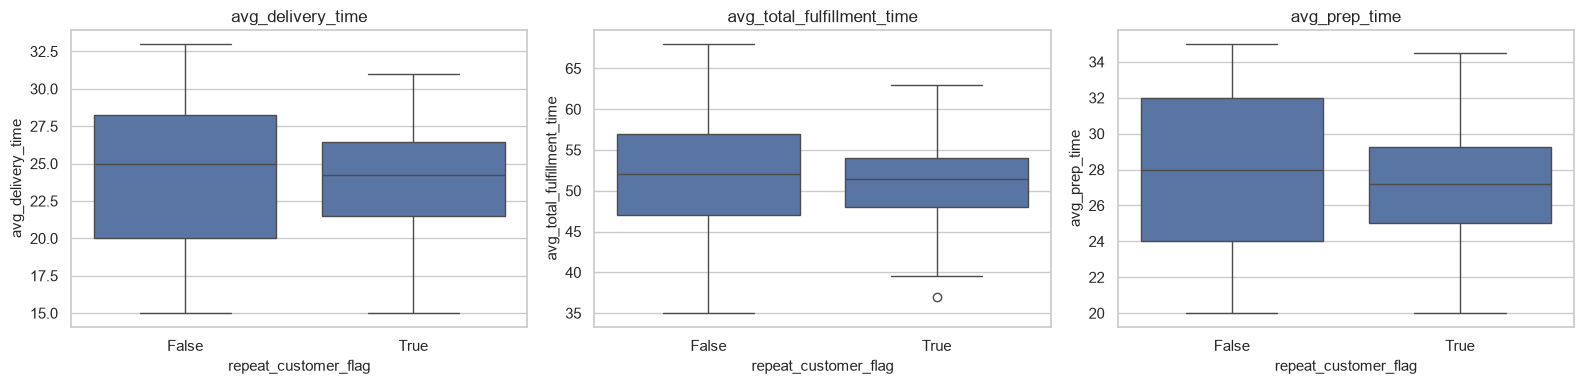

In [4]:
# Compare delivery speed by repeat_customer_flag
cols = ["avg_delivery_time", "avg_total_fulfillment_time", "avg_prep_time"]

fig, axes = plt.subplots(1, len(cols), figsize=(16, 4), sharey=False)

for ax, col in zip(axes, cols):
    sns.boxplot(data=customers, x="repeat_customer_flag", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("repeat_customer_flag")

plt.tight_layout()
plt.show()

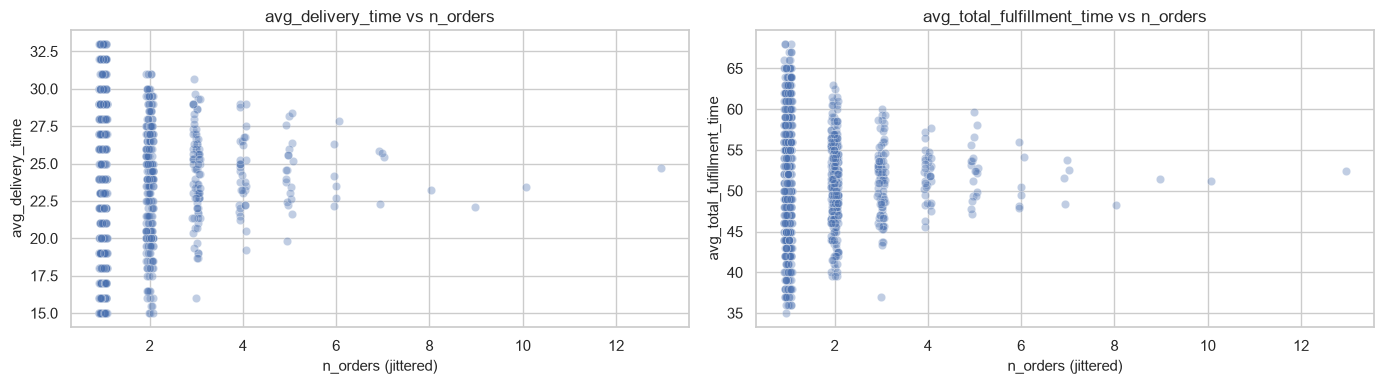

In [5]:
# Scatter: n_orders vs delivery speed proxies
# (jittered x to reduce overlap because n_orders is discrete)
plot_df = customers.copy()
plot_df["n_orders_jitter"] = plot_df["n_orders"] + np.random.uniform(-0.08, 0.08, size=len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.scatterplot(data=plot_df, x="n_orders_jitter", y="avg_delivery_time", alpha=0.35, ax=axes[0])
axes[0].set_title("avg_delivery_time vs n_orders")
axes[0].set_xlabel("n_orders (jittered)")

sns.scatterplot(data=plot_df, x="n_orders_jitter", y="avg_total_fulfillment_time", alpha=0.35, ax=axes[1])
axes[1].set_title("avg_total_fulfillment_time vs n_orders")
axes[1].set_xlabel("n_orders (jittered)")

plt.tight_layout()
plt.show()

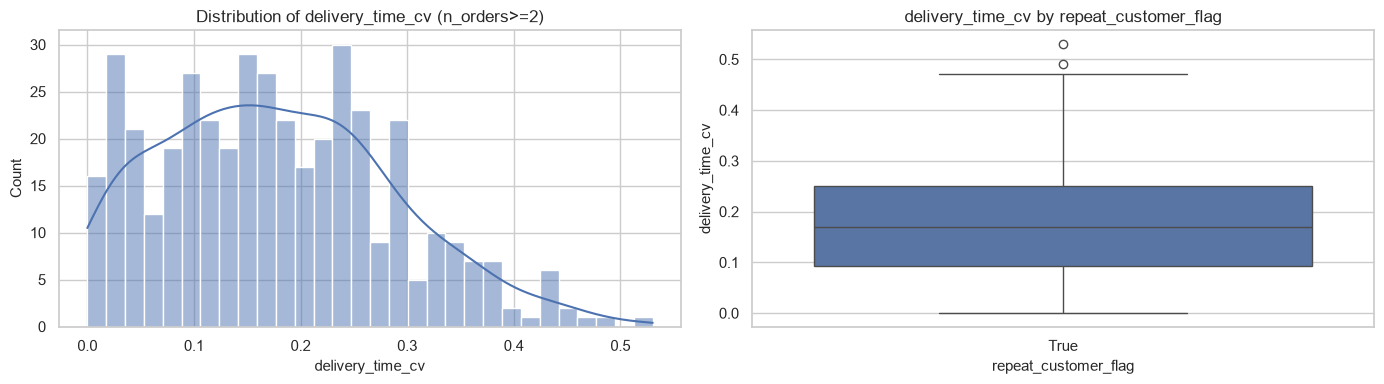

In [6]:
# Consistency proxies (only defined for customers with >=2 orders)
if "has_2plus_orders" in customers.columns:
    cons = customers.loc[customers["has_2plus_orders"] == True].copy()
else:
    cons = customers.loc[customers["n_orders"] >= 2].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=cons, x="delivery_time_cv", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of delivery_time_cv (n_orders>=2)")

sns.boxplot(data=cons, x="repeat_customer_flag", y="delivery_time_cv", ax=axes[1])
axes[1].set_title("delivery_time_cv by repeat_customer_flag")
axes[1].set_xlabel("repeat_customer_flag")

plt.tight_layout()
plt.show()

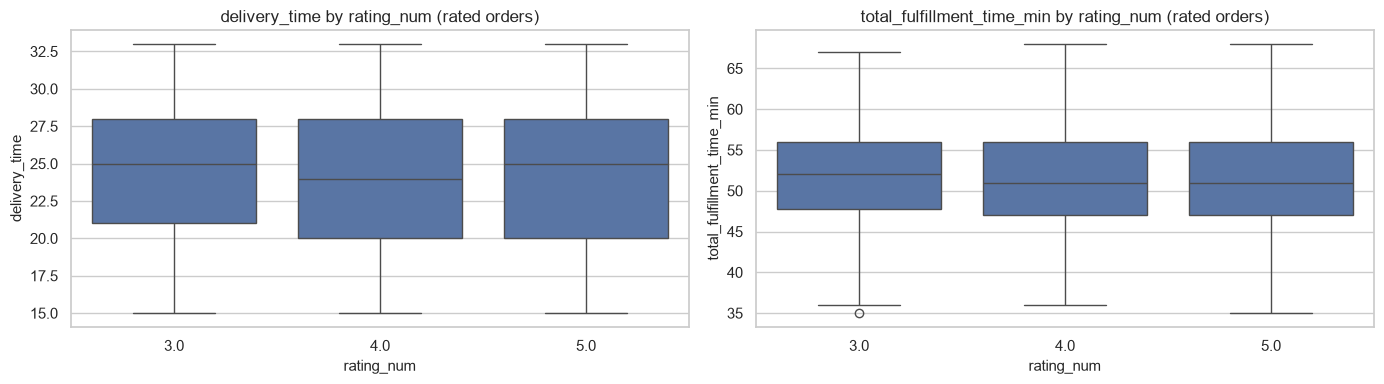

In [7]:
# Order-level: do slower deliveries correspond to lower ratings? (rated orders only)
rated_orders = orders.loc[orders["rated_flag"] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=rated_orders, x="rating_num", y="delivery_time", ax=axes[0])
axes[0].set_title("delivery_time by rating_num (rated orders)")
axes[0].set_xlabel("rating_num")

sns.boxplot(data=rated_orders, x="rating_num", y="total_fulfillment_time_min", ax=axes[1])
axes[1].set_title("total_fulfillment_time_min by rating_num (rated orders)")
axes[1].set_xlabel("rating_num")

plt.tight_layout()
plt.show()

## H2: Higher customer ratings ? higher repeat ordering

We visualize rating proxies vs engagement proxies:
- Rating proxies: `avg_rating`, `pct_top_rating`, `pct_high_rating` (computed among rated orders)
- Engagement proxies: `repeat_customer_flag`, `n_orders`

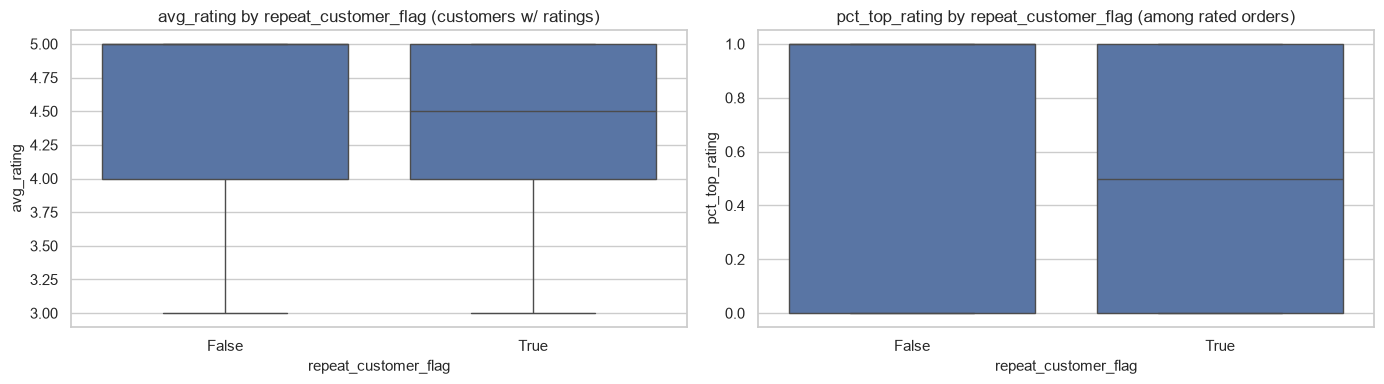

In [8]:
# Customers with at least one rated order
if "has_rated_orders" in customers.columns:
    cust_rated = customers.loc[customers["has_rated_orders"] == True].copy()
else:
    cust_rated = customers.loc[customers["rated_share"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=cust_rated, x="repeat_customer_flag", y="avg_rating", ax=axes[0])
axes[0].set_title("avg_rating by repeat_customer_flag (customers w/ ratings)")
axes[0].set_xlabel("repeat_customer_flag")

sns.boxplot(data=cust_rated, x="repeat_customer_flag", y="pct_top_rating", ax=axes[1])
axes[1].set_title("pct_top_rating by repeat_customer_flag (among rated orders)")
axes[1].set_xlabel("repeat_customer_flag")

plt.tight_layout()
plt.show()

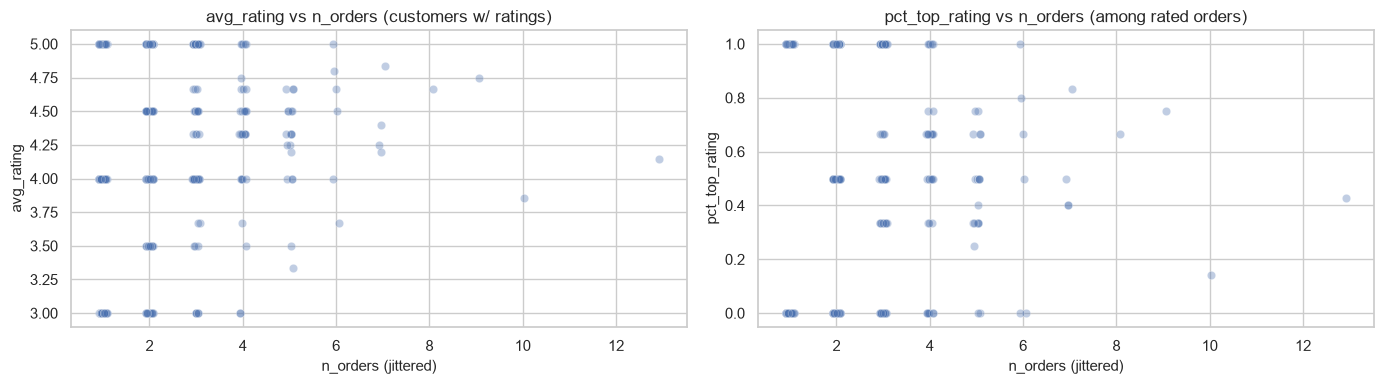

In [9]:
# Scatter: n_orders vs avg_rating / pct_top_rating
cust_rated = cust_rated.copy()
cust_rated["n_orders_jitter"] = cust_rated["n_orders"] + np.random.uniform(-0.08, 0.08, size=len(cust_rated))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.scatterplot(data=cust_rated, x="n_orders_jitter", y="avg_rating", alpha=0.35, ax=axes[0])
axes[0].set_title("avg_rating vs n_orders (customers w/ ratings)")
axes[0].set_xlabel("n_orders (jittered)")

sns.scatterplot(data=cust_rated, x="n_orders_jitter", y="pct_top_rating", alpha=0.35, ax=axes[1])
axes[1].set_title("pct_top_rating vs n_orders (among rated orders)")
axes[1].set_xlabel("n_orders (jittered)")

plt.tight_layout()
plt.show()

## H3: More variety (restaurants/cuisines) ? higher retention (proxy)

Variety proxies (customer-level):
- `restaurant_variety`
- `cuisine_variety`

Engagement proxies:
- `repeat_customer_flag`
- `n_orders`

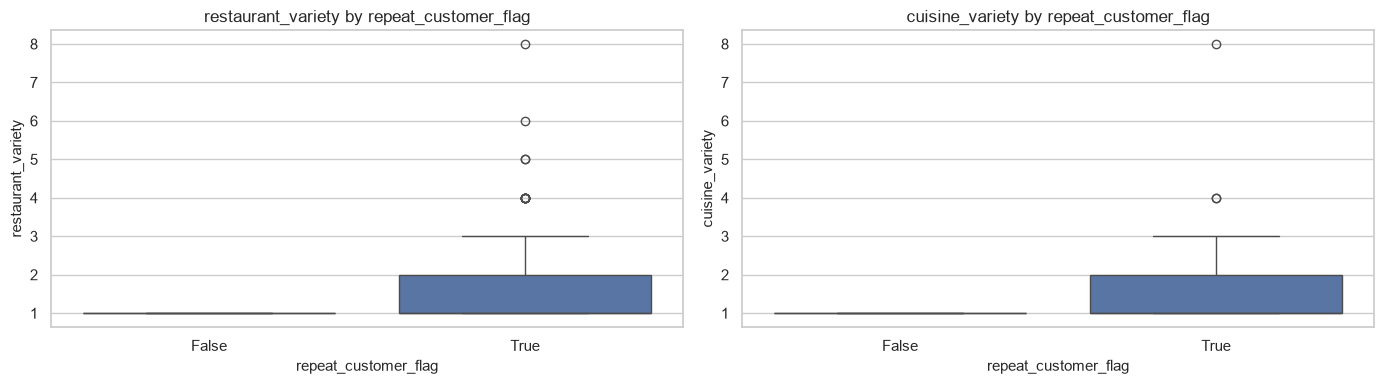

In [10]:
# Variety by repeat_customer_flag
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=customers, x="repeat_customer_flag", y="restaurant_variety", ax=axes[0])
axes[0].set_title("restaurant_variety by repeat_customer_flag")
axes[0].set_xlabel("repeat_customer_flag")

sns.boxplot(data=customers, x="repeat_customer_flag", y="cuisine_variety", ax=axes[1])
axes[1].set_title("cuisine_variety by repeat_customer_flag")
axes[1].set_xlabel("repeat_customer_flag")

plt.tight_layout()
plt.show()

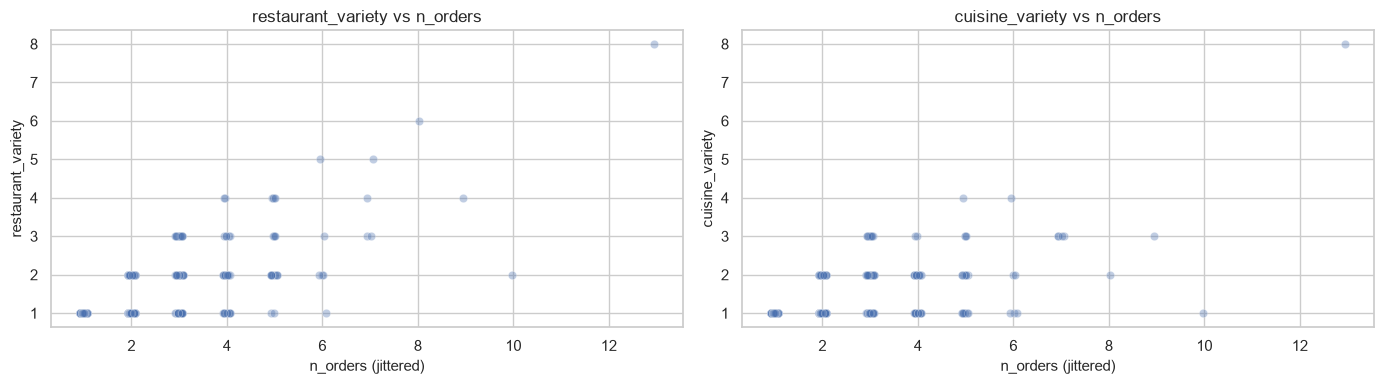

In [11]:
# Scatter: n_orders vs variety proxies
plot_df = customers.copy()
plot_df["n_orders_jitter"] = plot_df["n_orders"] + np.random.uniform(-0.08, 0.08, size=len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.scatterplot(data=plot_df, x="n_orders_jitter", y="restaurant_variety", alpha=0.35, ax=axes[0])
axes[0].set_title("restaurant_variety vs n_orders")
axes[0].set_xlabel("n_orders (jittered)")

sns.scatterplot(data=plot_df, x="n_orders_jitter", y="cuisine_variety", alpha=0.35, ax=axes[1])
axes[1].set_title("cuisine_variety vs n_orders")
axes[1].set_xlabel("n_orders (jittered)")

plt.tight_layout()
plt.show()

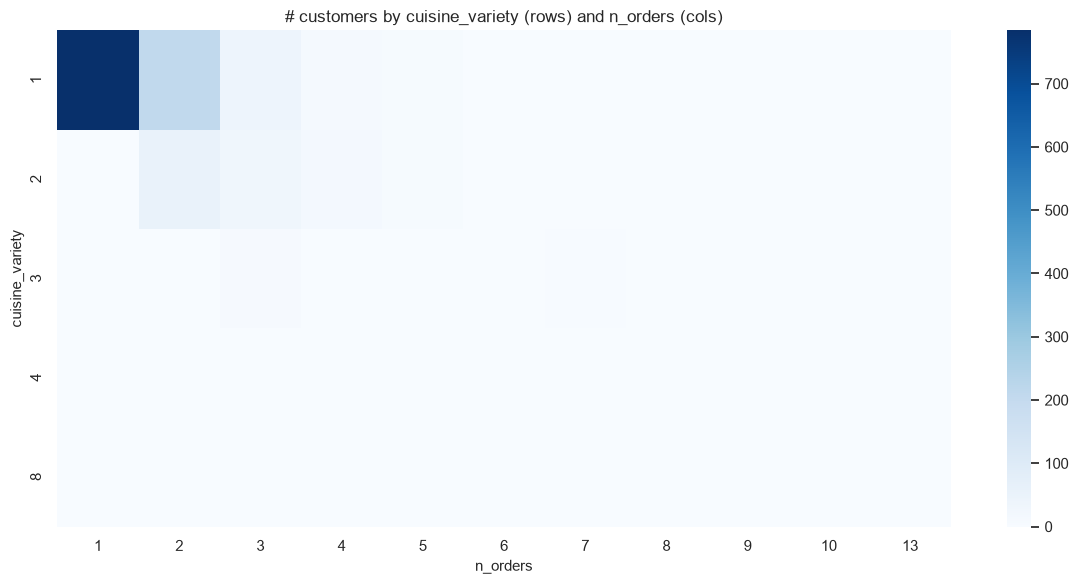

In [12]:
# Heatmap: customer counts by (n_orders, cuisine_variety)
# (helps see concentration of customers across discrete pairs)
ct = (
    customers
    .groupby(["n_orders", "cuisine_variety"], dropna=False)
    .size()
    .reset_index(name="n_customers")
)

pivot = ct.pivot(index="cuisine_variety", columns="n_orders", values="n_customers").fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="Blues")
plt.title("# customers by cuisine_variety (rows) and n_orders (cols)")
plt.xlabel("n_orders")
plt.ylabel("cuisine_variety")
plt.tight_layout()
plt.show()

## Extra: Correlation heatmap (customer-level numeric)

This is descriptive only and helps spot relationships worth exploring later.

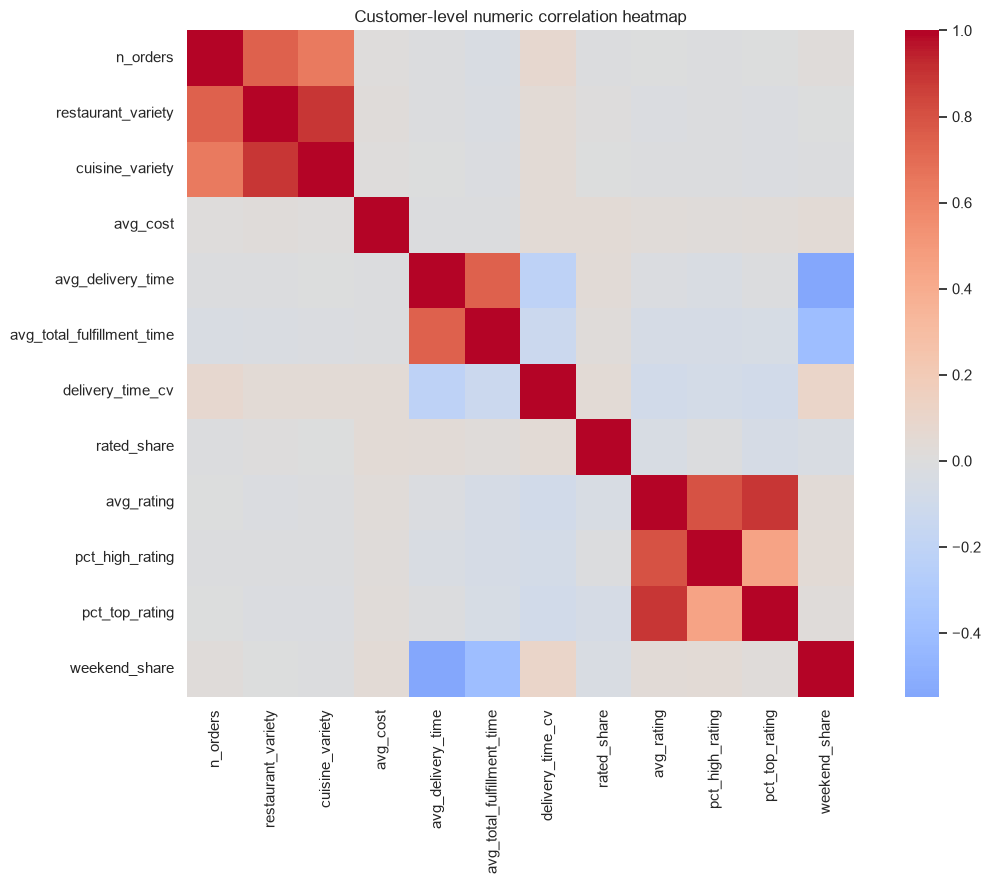

In [13]:
# Correlation heatmap (numeric columns)
num = customers.select_dtypes(include=["number"]).copy()

# Keep a focused set for readability
keep = [
    c for c in [
        "n_orders",
        "restaurant_variety",
        "cuisine_variety",
        "avg_cost",
        "avg_delivery_time",
        "avg_total_fulfillment_time",
        "delivery_time_cv",
        "rated_share",
        "avg_rating",
        "pct_high_rating",
        "pct_top_rating",
        "weekend_share",
    ]
    if c in num.columns
]

corr = num[keep].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Customer-level numeric correlation heatmap")
plt.tight_layout()
plt.show()